In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import sys
from pathlib import Path
from src.data import Pacman_Dataset, TorusLieWrapper, AngleTorusWrapper
from torch.utils.data import DataLoader


/home/jizho/projects/diffusion-playground/src/data.py:25: SyntaxWarning: invalid escape sequence '\i'
  """Map theta to x \in [a,b)"""


In [2]:
# file_path = Path(os.getcwd())
# project_path = file_path.parent
# project_path = os.fspath(project_path)
project_path = os.path.abspath('')
print(project_path)

/home/jizho/projects/diffusion-playground


In [3]:
data_directory = project_path + "/data"
pacman_data_dir = data_directory + "/pacman.npy"
pacman_np = np.load(pacman_data_dir)

Shape of pacman dataset: (486662, 2)


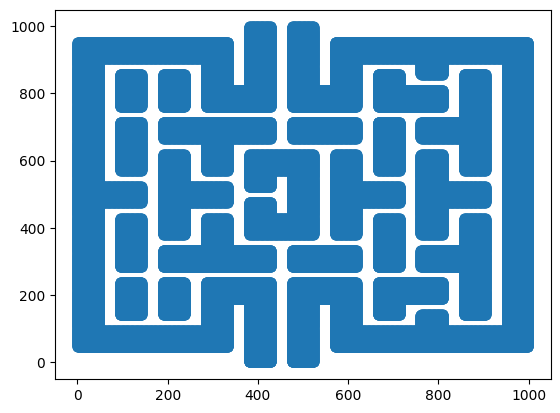

In [4]:
print("Shape of pacman dataset:", pacman_np.shape)

pacman_np
# sns.set_theme(style="whitegrid")
fig, ax = plt.subplots()
ax.scatter(x=pacman_np[:,0],y = pacman_np[:,1])
plt.show()
# sns.scatterplot(data=pacman_np)

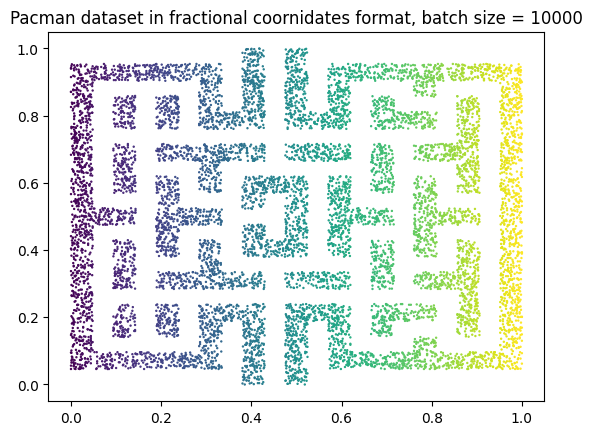

In [5]:
pacman_dataset = Pacman_Dataset(pacman_data_dir)

dataloader_fractional = DataLoader(pacman_dataset, batch_size=10000, shuffle=True)

batch_1_fractional = next(iter(dataloader_fractional))
fig, ax = plt.subplots()

ax.scatter(x=batch_1_fractional[:,0],y = batch_1_fractional[:,1], c = batch_1_fractional[:,0], cmap = "viridis", s = 0.5)
ax.set_title("Pacman dataset in fractional coornidates format, batch size = 10000")
plt.show()


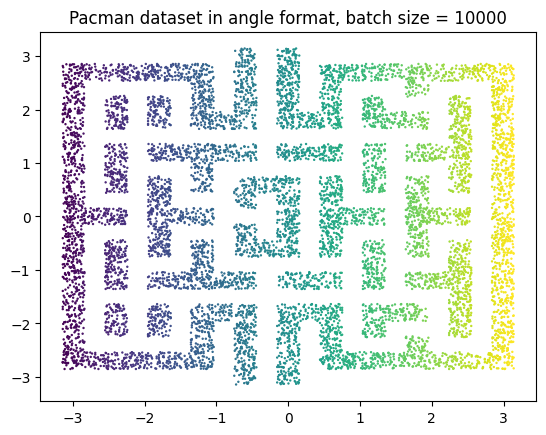

In [6]:


pacman_lie_dataset = TorusLieWrapper(pacman_dataset)
pacman_angle_dataset = AngleTorusWrapper(pacman_lie_dataset)
dataloader = DataLoader(pacman_angle_dataset, batch_size=10000, shuffle=True)
batch_1 = next(iter(dataloader))
fig, ax = plt.subplots()
ax.scatter(x=batch_1[:,0],y = batch_1[:,1], c = batch_1[:,0], cmap = "viridis", s = 0.5)
ax.set_title("Pacman dataset in angle format, batch size = 10000")
plt.show()



